In [415]:
"""
EDA setup:
- pandas for data handling
- numpy for numerical operations
- matplotlib / seaborn for visualization
- display options to inspect columns properly
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 1000)

sns.set_theme(style="whitegrid")

In [416]:
"""
Load the Titanic training dataset.
Always inspect whether loading worked correctly before moving ahead.
"""
df = pd.read_csv('../datasets/Titanic-Dataset.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Interpretation

This is your first visual contact with the dataset.
Do not move ahead blindly. You should immediately ask:

what each row represents
what the target is

what kind of variables exist
Markdown

Each row appears to represent one passenger aboard the Titanic, and the target variable is Survived, where 1 indicates survival and 0 indicates non-survival.

In [417]:
"""
Check the dimensionality of the dataset:
- number of rows
- number of columns
"""

print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape of dataset: (891, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


Interpretation

This tells you how large the dataset is and what variables are available.
A serious analyst immediately separates columns into:

target
identifiers
numeric
categorical
potentially engineered later
Markdown

The dataset contains a moderate number of observations and a mix of demographic, travel, and family-related features. At this stage, it is useful to begin mentally grouping variables by type and possible relevance to survival.

In [418]:
"""
Inspect data types and missingness at a structural level.
This is one of the most important early EDA steps.
"""

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Interpretation

This tells you:

which columns are numeric vs object
where missing values likely exist
whether some columns may need conversion
What you should notice
Age likely has missing values
Cabin likely has many missing values
Embarked may have a few missing values
some numeric-looking things may actually be categories, such as Pclass
Markdown

The dataset contains both numeric and object-type columns. At first glance, Age, Cabin, and possibly Embarked show missing values. Also, although Pclass is stored numerically, it should be interpreted as an ordinal categorical variable rather than a continuous numeric variable.

In [419]:
"""
Generate summary statistics for numeric columns.
This helps detect scale, spread, and suspicious values.
"""

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Interpretation

This gives quick information on:

mean vs median patterns
range
unusual extremes
whether some columns are highly skewed
What to observe
Fare often has strong right skew
Age may look broad but incomplete
PassengerId is not analytically meaningful even though it is numeric
Markdown

Summary statistics suggest that some variables, especially Fare, may be highly skewed. PassengerId is merely an identifier and should not be treated as a meaningful predictive feature.

🔴 WHAT df.describe() ACTUALLY GIVES YOU

For each numeric column:

count
mean
std
min
25%
50% (median)
75%
max

👉 But these are NOT numbers.
👉 These are signals about data behavior

🧠 THE ONLY WAY TO REMEMBER THIS

Every column → ask these 6 QUESTIONS

✅ 1. IS THE DATA COMPLETE?
Look at:
count
Ask:

Is count = total rows?

Example thinking:
Age count = 714  
Total rows = 891

👉 Missing exists

🧠 Interpretation:

“Age is incomplete. Any analysis involving age must account for missing values, otherwise conclusions may be biased.”

✅ 2. IS THE DATA SKEWED?
Look at:
mean vs median (50%)
Rule:
Condition	Meaning
mean > median	right skew
mean < median	left skew
mean ≈ median	symmetric
Example:
Fare:
mean = 32  
median = 14

👉 Strong right skew

🧠 Interpretation:

“A small number of passengers paid very high fares, pulling the mean upward. Median is a better representative of central tendency here.”

✅ 3. ARE THERE OUTLIERS?
Look at:
min vs max
IQR range (25% → 75%)
Quick logic:

If:

max >> 75%

👉 Outliers exist

Example:
Fare:
75% = 31  
max = 512

👉 Extreme outlier

🧠 Interpretation:

“A few passengers paid extremely high fares, indicating possible VIP or luxury travel. These values may distort averages.”

✅ 4. WHAT IS THE SPREAD?
Look at:
std (standard deviation)
range (max - min)
Ask:

Is data tightly packed or widely spread?

Example:
Age std ≈ 14

👉 moderate spread

🧠 Interpretation:

“Age varies widely across passengers, suggesting multiple age groups are present rather than a concentrated demographic.”

✅ 5. DOES THE DATA MAKE SENSE?
Look at:
min
max
Ask:

Are values realistic?

Example:
Age min = 0.42

👉 infant → valid

But if:

Age = -5

👉 impossible → data error

🧠 Interpretation:

“No impossible values observed, suggesting data integrity is reasonable.”

✅ 6. IS THIS COLUMN EVEN USEFUL?
Look at:
meaning, not numbers
Example:
PassengerId:
mean = 445

👉 meaningless

🧠 Interpretation:

“Although numeric, PassengerId is an identifier and carries no predictive value.”

🔥 PUTTING IT ALL TOGETHER (REAL EXAMPLE)
Column: Fare
Observations:
mean >> median → skewed
max very high → outliers
std high → wide spread
💡 STRONG INTERPRETATION:

“Fare shows a highly right-skewed distribution with extreme outliers, indicating that while most passengers paid relatively low amounts, a small subset paid significantly higher fares. This suggests socioeconomic disparity among passengers, and median or log-transformed values may be more appropriate for analysis.”

👉 THIS is what makes you stand out.

🔴 WHAT MOST PEOPLE DO (AND YOU MUST AVOID)

❌ “Fare is skewed”
❌ “There are outliers”
❌ “Mean is higher”

👉 This is data reading, not analysis.

🔴 WHAT YOU SHOULD DO

Always write:

👉 WHAT
👉 WHY
👉 SO WHAT

Example:
WHAT

Fare is right-skewed

WHY

Few passengers paid very high prices

SO WHAT

Mean is misleading → use median/log transform

🧠 MEMORY TRICK (VERY IMPORTANT)

Whenever you see describe()
run this in your head:

C-S-S-O-S-U

C → Completeness
S → Skewness
S → Spread
O → Outliers
S → Sanity check
U → Usefulness
🔥 HARSH TRUTH

If you don’t master describe():

your EDA will be shallow
your interviews will expose you
your models will be weak

In [420]:
"""
Create a clean missing-value summary.
This is better than only using df.isnull().sum().
"""

missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df)) * 100
}).sort_values(by="missing_percent", ascending=False)

missing

,missing_count,missing_percent
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
SibSp,0,0.000000
Parch,0,0.000000


Interpretation

This is where real EDA starts.

You are not just checking what is missing.
You are asking:

is the missingness random?
is the missingness informative?
should it be imputed, grouped, or left alone?
Strong interpretation

Cabin has the highest missingness by far, suggesting that cabin information was not consistently recorded for all passengers. This missingness may itself carry social-class information, since cabin data was more likely to be documented for higher-class passengers. Age also has substantial missingness, meaning any age-based analysis must be handled carefully.

In [421]:
"""
Examine the distribution of the target variable.
This tells us whether the classes are balanced.
"""

survival_counts = df["Survived"].value_counts()
survival_rate = df["Survived"].mean()

print(survival_counts)
print(f"\nOverall survival rate: {survival_rate:.2%}")

Survived
0    549
1    342
Name: count, dtype: int64

Overall survival rate: 38.38%


Interpretation

This answers the first important business question:

how many survived overall?
Markdown

The overall survival rate provides a baseline for all later comparisons. If the dataset is imbalanced, model evaluation must be done carefully, since naive accuracy may be misleading.

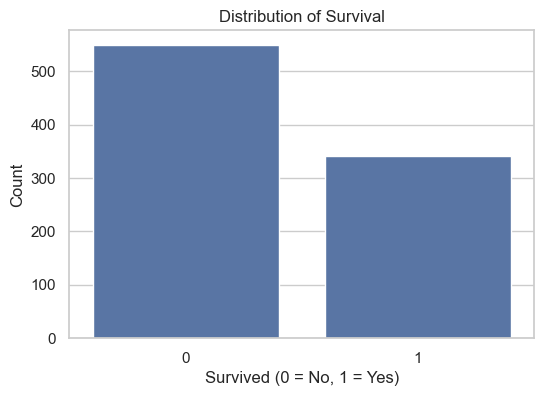

In [422]:
"""
Plot the count of survivors vs non-survivors.
A visual check often communicates class balance better than plain numbers.
"""

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Survived")
plt.title("Distribution of Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

Interpretation

Visual confirmation helps you see if the problem is heavily imbalanced or reasonably distributed.

Markdown

The target distribution shows that non-survivors outnumber survivors, indicating that survival was not the majority outcome. This is important context for both EDA and later modeling.


--- Pclass ---
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


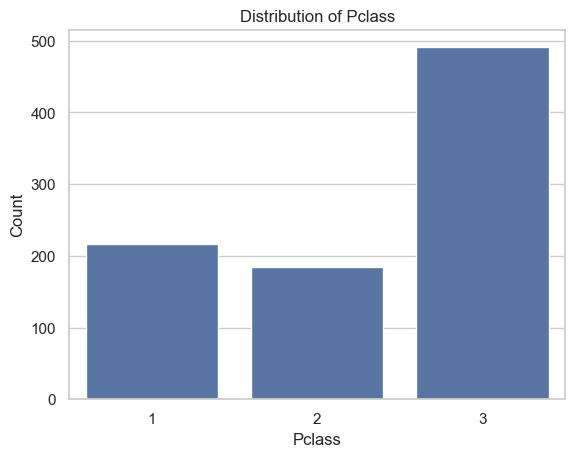


--- Sex ---
Sex
male      577
female    314
Name: count, dtype: int64


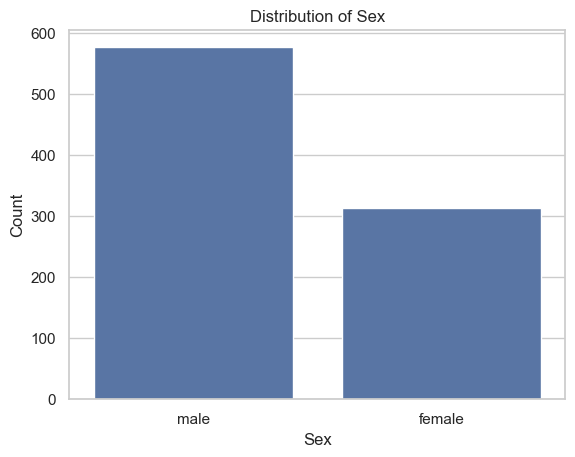


--- Embarked ---
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64


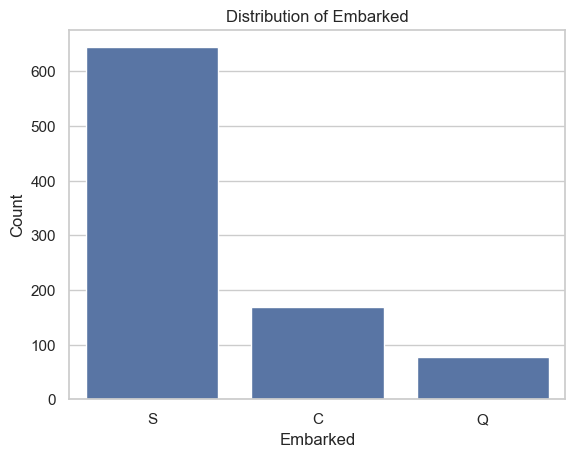


--- SibSp ---
SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


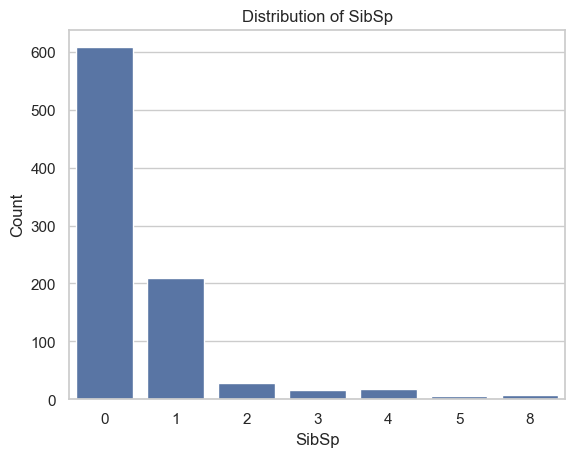


--- Parch ---
Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


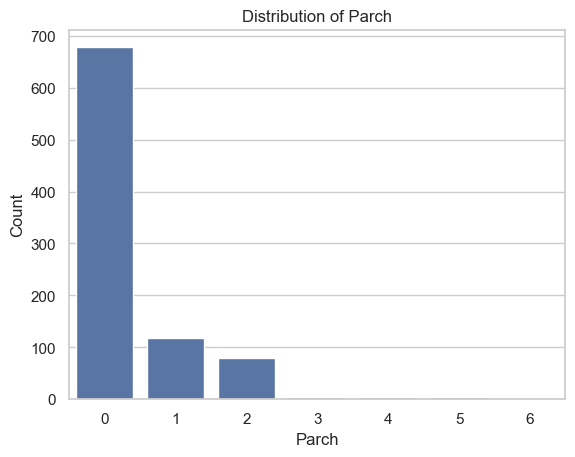

In [423]:
"""
Inspect categorical-like columns using value counts.
This gives a first look at class composition and common categories.
"""
categorical_cols = ["Pclass", "Sex", "Embarked", "SibSp", "Parch"]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    
    counts = df[col].value_counts(dropna=False)
    print(counts)
    
    # Plot
    sns.barplot(x=counts.index, y=counts.values)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

Interpretation

You are checking composition, imbalance, and weird values.

What to observe
more males than females
more passengers in 3rd class
Embarked may have dominant categories
SibSp and Parch are numeric but often treated as count-based categorical/discrete variables
Markdown

Several variables are discrete or categorical in nature even when stored numerically. For example, Pclass represents passenger class rather than a continuous measure, and SibSp/Parch represent small-count family relationships rather than true continuous quantities.

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


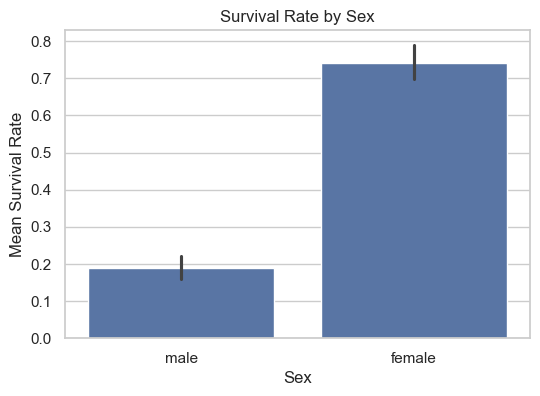

In [424]:
"""
Compare survival rates across sex.
This is one of the strongest known signals in the Titanic dataset.
"""

survival_by_sex = df.groupby("Sex")["Survived"].mean().sort_values(ascending=False)
print(survival_by_sex)

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="Sex", y="Survived")
plt.title("Survival Rate by Sex")
plt.ylabel("Mean Survival Rate")
plt.show()

Interpretation

This is where you stop being shallow.

Do not write:

females survived more

Write:

Female passengers show a substantially higher survival rate, which likely reflects evacuation norms such as “women and children first,” indicating that survival was influenced not only by physical conditions but also by social rules and rescue priorities.

That is the difference between average and strong analysis.

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


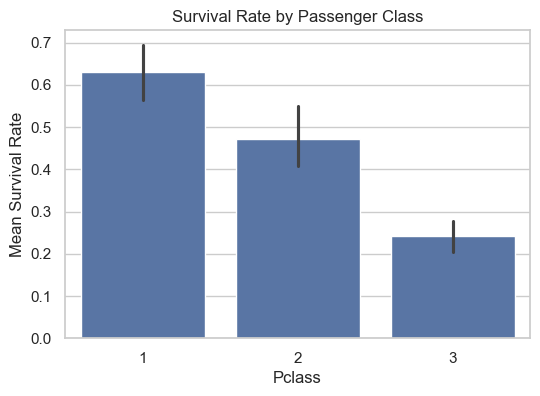

In [425]:
"""
Compare survival rates across passenger classes.
Passenger class may reflect social status, cabin access, and physical location on the ship.
"""

survival_by_class = df.groupby("Pclass")["Survived"].mean().sort_index()
print(survival_by_class)

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="Pclass", y="Survived")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Mean Survival Rate")
plt.show()

Interpretation

Do not write:

first class survived more

Write:

Survival rates decrease from first to third class, suggesting that economic class strongly influenced outcomes. This may reflect differences in cabin location, access to lifeboats, crew attention, and overall priority during evacuation.

That is intelligent interpretation.

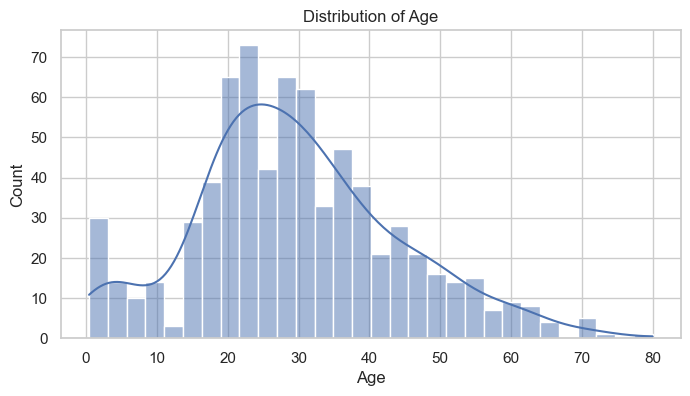

In [426]:
"""
Inspect age distribution to understand spread, skewness, and missing-value impact.
"""

plt.figure(figsize=(8, 4))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Interpretation

Ask:

Are children common?
Is age concentrated in young adults?
Are there outliers?
Does missingness distort the picture?
Markdown

The age distribution appears concentrated around young and middle adulthood, with fewer elderly passengers. Since age contains missing values, the observed pattern may not fully represent the true age structure of all passengers.

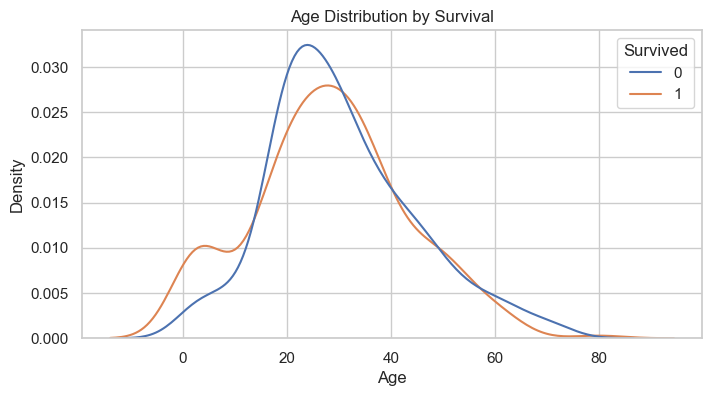

In [427]:
"""
Compare age distributions for survivors and non-survivors.
This helps identify whether age may have influenced evacuation priority.
"""

plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x="Age", hue="Survived", common_norm=False)
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

Interpretation

You are not only checking whether age matters.
You are checking how it matters.

Markdown

Comparing age distributions across survival groups may reveal whether children or younger passengers had a relative survival advantage. This would be consistent with rescue norms that prioritized younger and more vulnerable individuals.

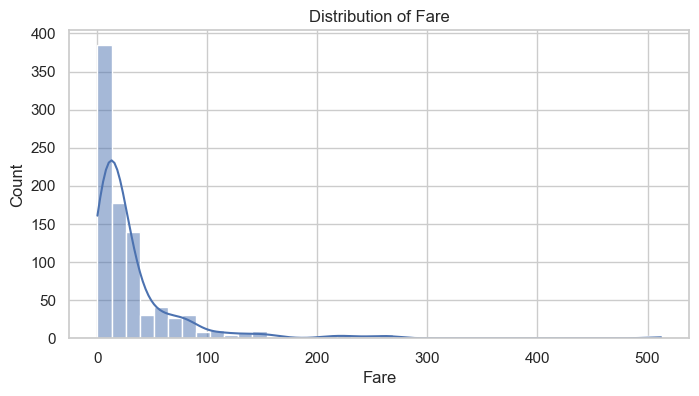

In [428]:
"""
Inspect fare distribution.
Fare is usually highly skewed and may capture socioeconomic privilege.
"""

plt.figure(figsize=(8, 4))
sns.histplot(df["Fare"], bins=40, kde=True)
plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

Interpretation

Fare is rarely normal.
It is usually right-skewed.

Markdown

Fare appears strongly right-skewed, with a small number of passengers paying much higher amounts. This suggests that fare may proxy wealth and class privilege, but it may also need transformation for later modeling.

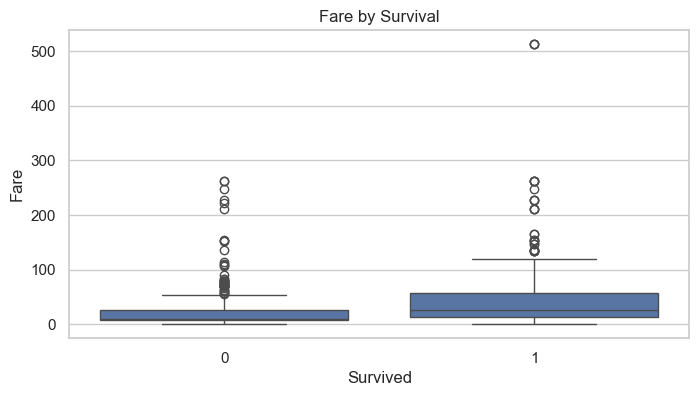

In [429]:
"""
Use a boxplot to compare fare distributions across survival groups.
This helps assess whether higher-paying passengers had better outcomes.
"""

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Survived", y="Fare")
plt.title("Fare by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.show()

Interpretation

This is not proof of causation.
It is evidence of association.

Markdown

Survivors appear to have paid higher fares on average, which may reflect the broader effect of socioeconomic advantage. However, fare is also entangled with passenger class and possibly cabin location, so this relationship should not be interpreted in isolation.

Cabin_known
0    0.299854
1    0.666667
Name: Survived, dtype: float64


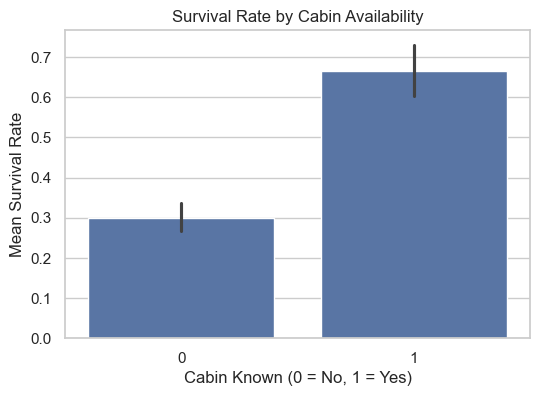

In [430]:
"""
Create a binary feature indicating whether cabin information is available.
Missingness itself may contain useful signal.
"""

df["Cabin_known"] = df["Cabin"].notnull().astype(int)

print(df.groupby("Cabin_known")["Survived"].mean())

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="Cabin_known", y="Survived")
plt.title("Survival Rate by Cabin Availability")
plt.xlabel("Cabin Known (0 = No, 1 = Yes)")
plt.ylabel("Mean Survival Rate")
plt.show()

Interpretation

This is the kind of move that separates thinkers from tutorial followers.

Markdown

Passengers with recorded cabin information may show higher survival rates. Rather than treating cabin missingness as mere inconvenience, it can be interpreted as potentially informative, likely linked to class, documentation quality, or cabin assignment patterns.

In [431]:
"""
Create family size from SibSp and Parch.
Being alone versus traveling with family may affect survival.
"""

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

print(df.groupby("IsAlone")["Survived"].mean())
print(df.groupby("FamilySize")["Survived"].mean())

IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64
FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


Interpretation

This is feature engineering based on human reasoning.

Markdown

Family structure may influence survival in non-linear ways. Passengers traveling alone may have behaved differently from those traveling with immediate family, while very large family groups may have faced coordination difficulties during evacuation.

In [432]:
"""
Extract titles from passenger names.
Titles may encode gender, age, marital status, or social standing.
"""

df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.")
df["Title"] = df["Title"].str.strip()

print(df["Title"].value_counts())
print(df.groupby("Title")["Survived"].mean().sort_values(ascending=False))

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64
Title
the Countess    1.000000
Mlle            1.000000
Sir             1.000000
Ms              1.000000
Lady            1.000000
Mme             1.000000
Mrs             0.792000
Miss            0.697802
Master          0.575000
Col             0.500000
Major           0.500000
Dr              0.428571
Mr              0.156673
Jonkheer        0.000000
Rev             0.000000
Don             0.000000
Capt            0.000000
Name: Survived, dtype: float64


Interpretation

This is exactly why saying “Name is useless” is weak thinking.

Markdown

Passenger names contain embedded social information through honorific titles such as Mr, Mrs, Miss, and Master. These titles may proxy gender, age group, and social role, making them potentially more informative than the raw name string itself.

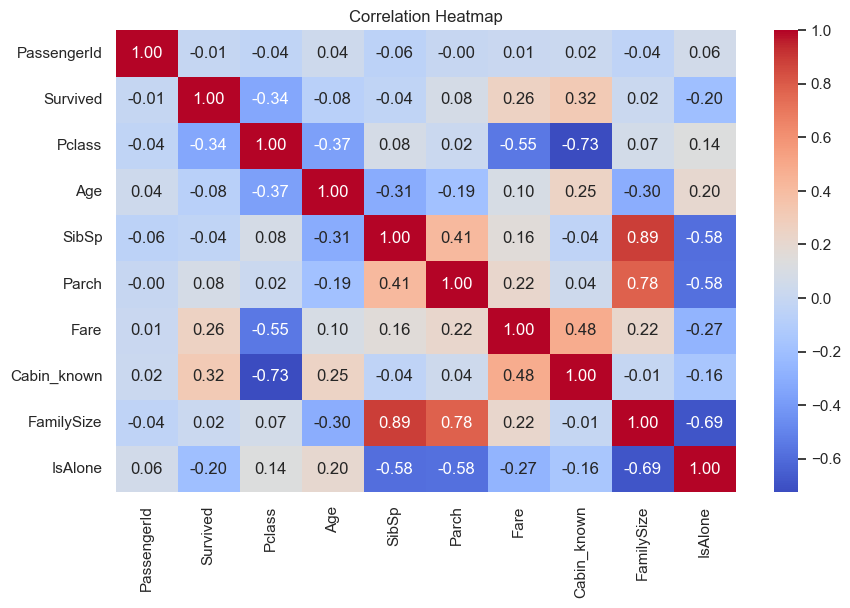

In [433]:
"""
Inspect correlations among numeric variables.
Correlation does not imply causation, but it helps identify linear associations.
"""

numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Interpretation

Use this carefully.
Do not worship correlation.

Markdown

Correlation analysis provides a quick view of linear associations between numeric variables. However, these values should be interpreted cautiously, especially since many important variables in this dataset are categorical or socially structured rather than purely numeric.

In [434]:
"""
Summarize the main findings from early EDA.
This is where analysis becomes communication.
"""

eda_summary = """
Key findings from early EDA:

1. Survival was not evenly distributed across passengers.
2. Sex appears strongly associated with survival, likely reflecting evacuation norms.
3. Passenger class also shows a strong relationship with survival, suggesting that social and spatial privilege mattered.
4. Age may play an important role, but missing values require careful handling.
5. Fare is highly skewed and may capture wealth-related survival advantages.
6. Cabin missingness is substantial and may itself be informative.
7. Family-based features and extracted name titles could improve later analysis and modeling.
"""

print(eda_summary)


Key findings from early EDA:

1. Survival was not evenly distributed across passengers.
2. Sex appears strongly associated with survival, likely reflecting evacuation norms.
3. Passenger class also shows a strong relationship with survival, suggesting that social and spatial privilege mattered.
4. Age may play an important role, but missing values require careful handling.
5. Fare is highly skewed and may capture wealth-related survival advantages.
6. Cabin missingness is substantial and may itself be informative.
7. Family-based features and extracted name titles could improve later analysis and modeling.



Interpretation

This is where most people fail.
They do analysis but cannot summarize.

Markdown

Early EDA suggests that Titanic survival was shaped not only by personal traits such as sex and age, but also by structural and social factors such as class, fare, and access-related information embedded in cabin and title features.

In [435]:
df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.")
df["Title"] = df["Title"].str.strip()

In [436]:
counts = df['Title'].value_counts()

rare_titles = counts[counts < 8].index

rare_titles= df[df['Title'].isin(rare_titles)]['Title'].tolist()
print(rare_titles)

['Don', 'Rev', 'Rev', 'Dr', 'Rev', 'Dr', 'Mme', 'Dr', 'Ms', 'Major', 'Major', 'Lady', 'Sir', 'Rev', 'Dr', 'Mlle', 'Col', 'Dr', 'Col', 'Mlle', 'Capt', 'the Countess', 'Dr', 'Dr', 'Jonkheer', 'Rev', 'Rev']


In [437]:

df["Title"] = df["Title"].replace(rare_titles, "Rare")

In [438]:
df['Title'].unique()

df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

In [439]:
df['Title'].unique()
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cabin_known,FamilySize,IsAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,2,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,2,0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,2,0,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,1,1,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0,1,1,Rare
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,1,1,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,0,4,0,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,1,1,Mr


In [440]:
df["Age"] = df["Age"].fillna(df.groupby("Title")["Age"].transform("median"))
df["Age"]

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    21.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [441]:
df = pd.get_dummies(df, columns=["Sex", "Embarked", "Title"], drop_first=True)

In [442]:
features = [
    "Pclass", "Age", "Fare",
    "FamilySize", "IsAlone", "Cabin_known"
] + [col for col in df.columns if "Sex_" in col or "Embarked_" in col or "Title_" in col]

X = df[features]
y = df["Survived"]
features

['Pclass',
 'Age',
 'Fare',
 'FamilySize',
 'IsAlone',
 'Cabin_known',
 'Sex_male',
 'Embarked_Q',
 'Embarked_S',
 'Title_Miss',
 'Title_Mr',
 'Title_Mrs',
 'Title_Rare']

In [443]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [444]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

model = LogisticRegression(max_iter=1000)
model2 = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8
)
model3 = RandomForestClassifier(criterion='gini',
                                           n_estimators=1750,
                                           max_depth=7,
                                           min_samples_split=6,
                                           min_samples_leaf=6,
                                           oob_score=True,
                                           random_state=42,
                                           n_jobs=-1,
                                           verbose=1) 
model.fit(X_train, y_train)
model2.fit(X_train, y_train)
model3.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_linea

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1750
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",6
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [445]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
y_pred2 = model2.predict(X_test)
y_pred3 = model3.predict(X_test)

print('-' * 90)
print("Logistic Regression\n")
print('-' * 90)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

print('-' * 90)
print("XGBoostClassifier\n")
print('-' * 90)
print("Accuracy:", accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))

print('-' * 90)
print("RandomeForest Classifier\n")
print('-' * 90)
print("Accuracy:", accuracy_score(y_test, y_pred3))
print(classification_report(y_test, y_pred3))

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


------------------------------------------------------------------------------------------
Logistic Regression

------------------------------------------------------------------------------------------
Accuracy: 0.8212290502793296
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       105
           1       0.78      0.78      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179

------------------------------------------------------------------------------------------
XGBoostClassifier

------------------------------------------------------------------------------------------
Accuracy: 0.8324022346368715
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       105
           1       0.80      0.80      0.80        74

    accuracy                           0.83    

[Parallel(n_jobs=14)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    0.0s
[Parallel(n_jobs=14)]: Done 172 tasks      | elapsed:    0.0s
[Parallel(n_jobs=14)]: Done 422 tasks      | elapsed:    0.0s
[Parallel(n_jobs=14)]: Done 772 tasks      | elapsed:    0.0s
[Parallel(n_jobs=14)]: Done 1222 tasks      | elapsed:    0.1s
[Parallel(n_jobs=14)]: Done 1750 out of 1750 | elapsed:    0.1s finished


In [446]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False) 
coefficients 
df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Cabin_known,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,0,2,0,True,False,True,False,True,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,1,2,0,False,False,False,False,False,True,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,1,1,False,False,True,True,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,1,2,0,False,False,True,False,False,True,False
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,0,1,1,True,False,True,False,True,False,False


In [447]:
df.sample(20)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Cabin_known,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
704,705,0,3,"Hansen, Mr. Henrik Juul",26.0,1,0,350025,7.8542,NaN,0,2,0,True,False,True,False,True,False,False
309,310,1,1,"Francatelli, Miss. Laura Mabel",30.0,0,0,PC 17485,56.9292,E36,1,1,1,False,False,False,True,False,False,False
601,602,0,3,"Slabenoff, Mr. Petco",30.0,0,0,349214,7.8958,NaN,0,1,1,True,False,True,False,True,False,False
155,156,0,1,"Williams, Mr. Charles Duane",51.0,0,1,PC 17597,61.3792,NaN,0,2,0,True,False,False,False,True,False,False
757,758,0,2,"Bailey, Mr. Percy Andrew",18.0,0,0,29108,11.5000,NaN,0,1,1,True,False,True,False,True,False,False
816,817,0,3,"Heininen, Miss. Wendla Maria",23.0,0,0,STON/O2. 3101290,7.9250,NaN,0,1,1,False,False,True,True,False,False,False
443,444,1,2,"Reynaldo, Ms. Encarnacion",28.0,0,0,230434,13.0000,NaN,0,1,1,False,False,True,False,False,False,True
36,37,1,3,"Mamee, Mr. Hanna",30.0,0,0,2677,7.2292,NaN,0,1,1,True,False,False,False,True,False,False
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",21.0,1,2,W./C. 6607,23.4500,NaN,0,4,0,False,False,True,True,False,False,False
500,501,0,3,"Calic, Mr. Petar",17.0,0,0,315086,8.6625,NaN,0,1,1,True,False,True,False,True,False,False
